##Syllabus Machine Learning II

**Week 6: Clustering algorithms**

*   K-means
*   Hierarchical clustering

In [1]:
# Mount Drive files
from google.colab import drive
import sys, os

# Uncomment for mounting drive files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 5/utils.py" /content
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 5/data" /content/data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import math
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import datetime

# Matplotlib Options
plt.rcParams['figure.figsize'] = [16, 8]
font = {'weight' : 'bold',
        'size'   : 14}
plt.rc('font', **font)

# Pandas options
pd.set_option("display.max_columns", None)

# Our custom models
from utils import (
    plot_centroids, plot_centroids_customers,
    plot_clusters, getImage,
    plot_customers_hierarchical,
    plot_hierarchical_cluster,
    pairwise_euclidean_distances,
    plot_dendrogram
)

# The K-Means Algorithm - Walkthrough

**K-means is an unsupervised learning algorithm used to cluster data into groups (or "clusters") based on similarity.** It works by mapping a fixed number (k) of clusters in a dataset based on distances. The algorithm iteratively assigns each data point to the nearest cluster center, and then re-computes the cluster centers based on the average of all the data points in the cluster. This process continues until the cluster assignments do not change or a maximum number of iterations is reached.

K-means is often used for exploratory data analysis, as a way to quickly summarize and visualize patterns in a dataset.

Let's start by loading a customer database with three variables:


*   Age
*   Annual Income
*   Average Spending


For the first example, I'm going to select 20 random customers from the group.

In [3]:
customers = pd.read_csv('/content/data/CustomerData.csv')
customer_sample = customers.sample(20, random_state=23)

Let's visualize the `age` and `annual income` of these customers:

Text(0, 0.5, 'Annual Income')

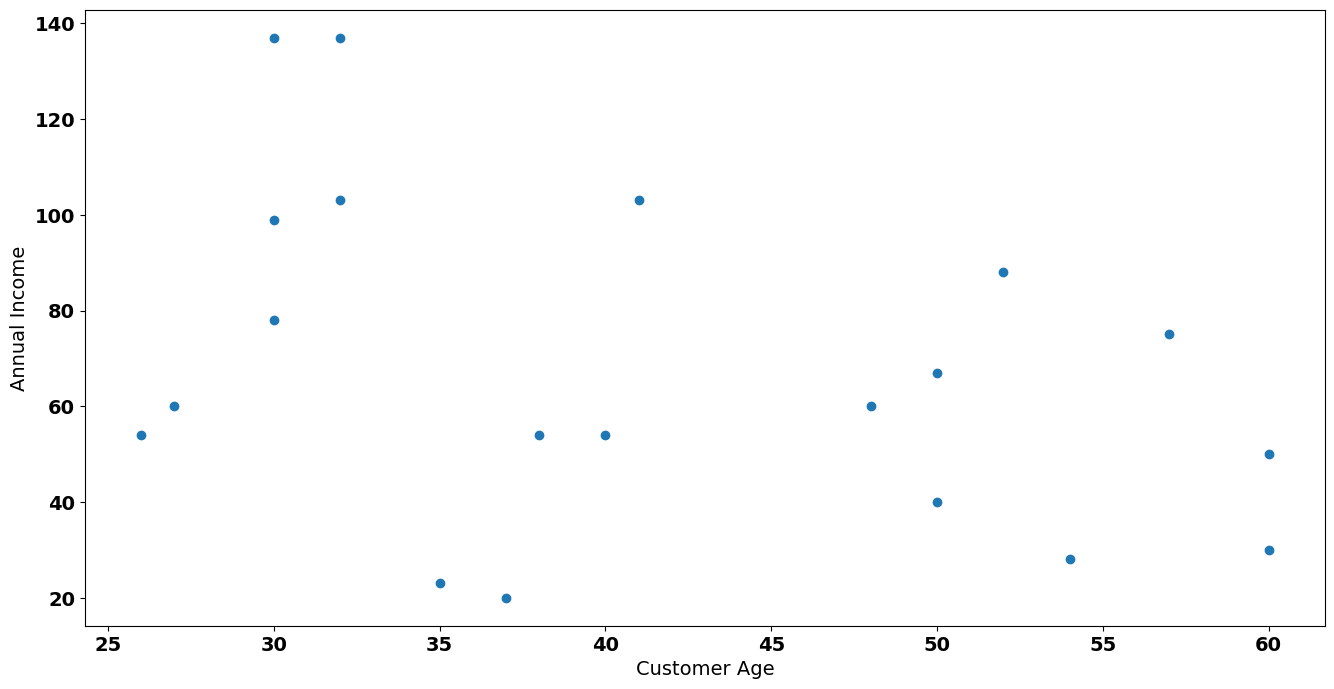

In [4]:
plt.scatter(customer_sample.age, customer_sample.annual_income)
plt.xlabel('Customer Age')
plt.ylabel('Annual Income')

**How many groups of customers do you see here?**

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

Let's start with two and randomnly throw **two centroids** in there:

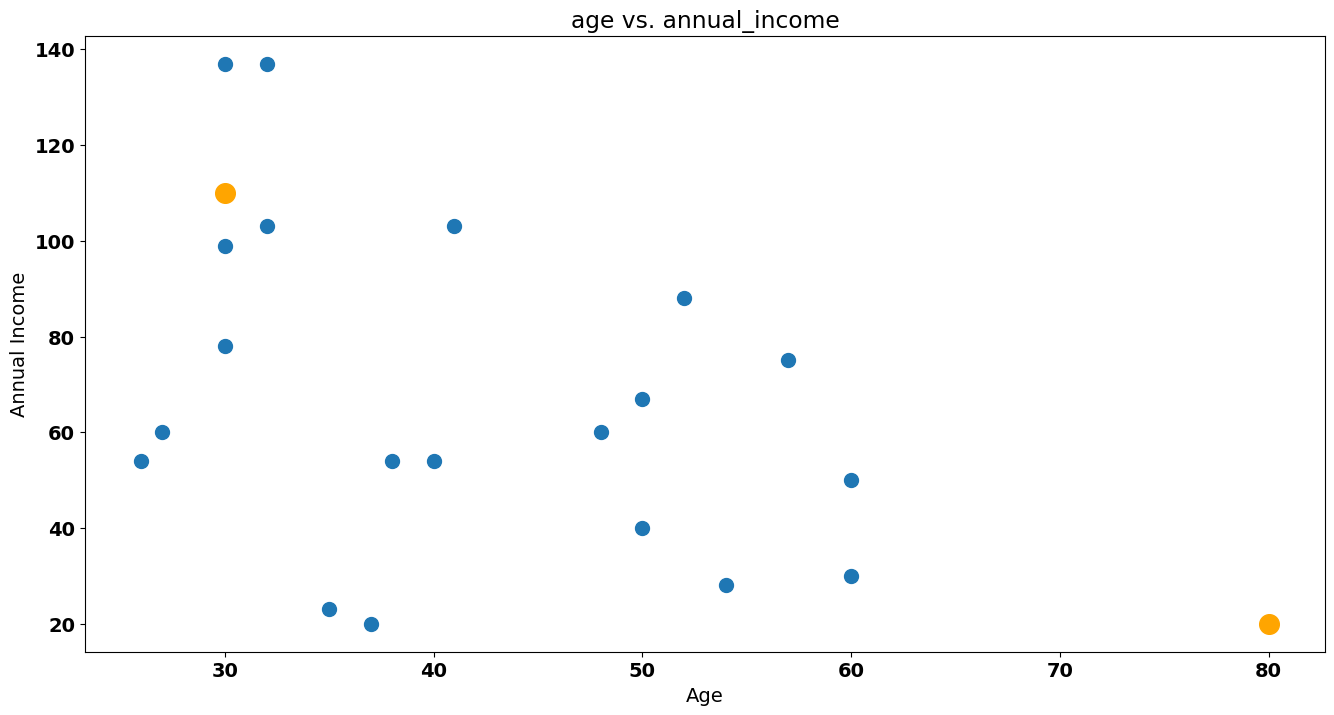

In [5]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]]
  )

plt.show()

Each point will be allocated to it's "centroid" based on the distance between itself and the centroid - for example, for this customer, *Mr. Steve*:

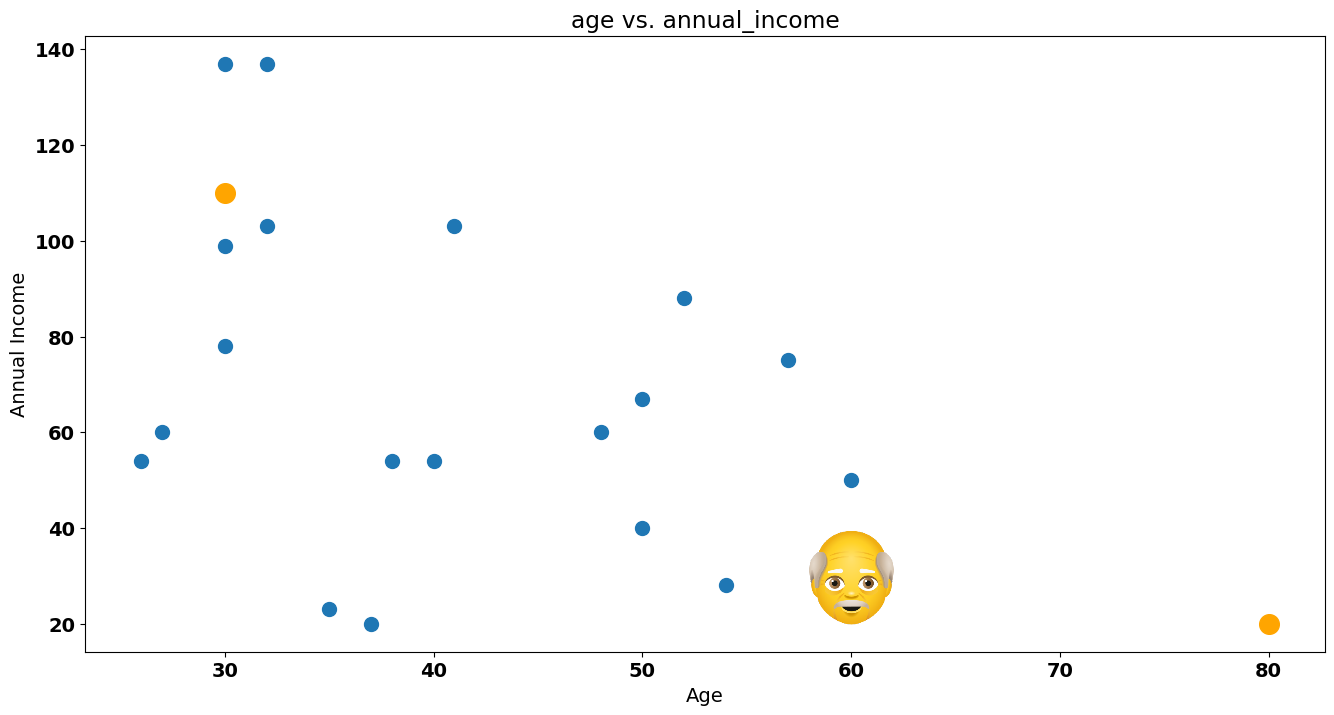

In [6]:
plot_centroids_customers(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]],
    'https://img.icons8.com/emoji/256/old-man-emo.png',
    60,
    30
)
plt.show()

How far is Steve from each centroid?

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

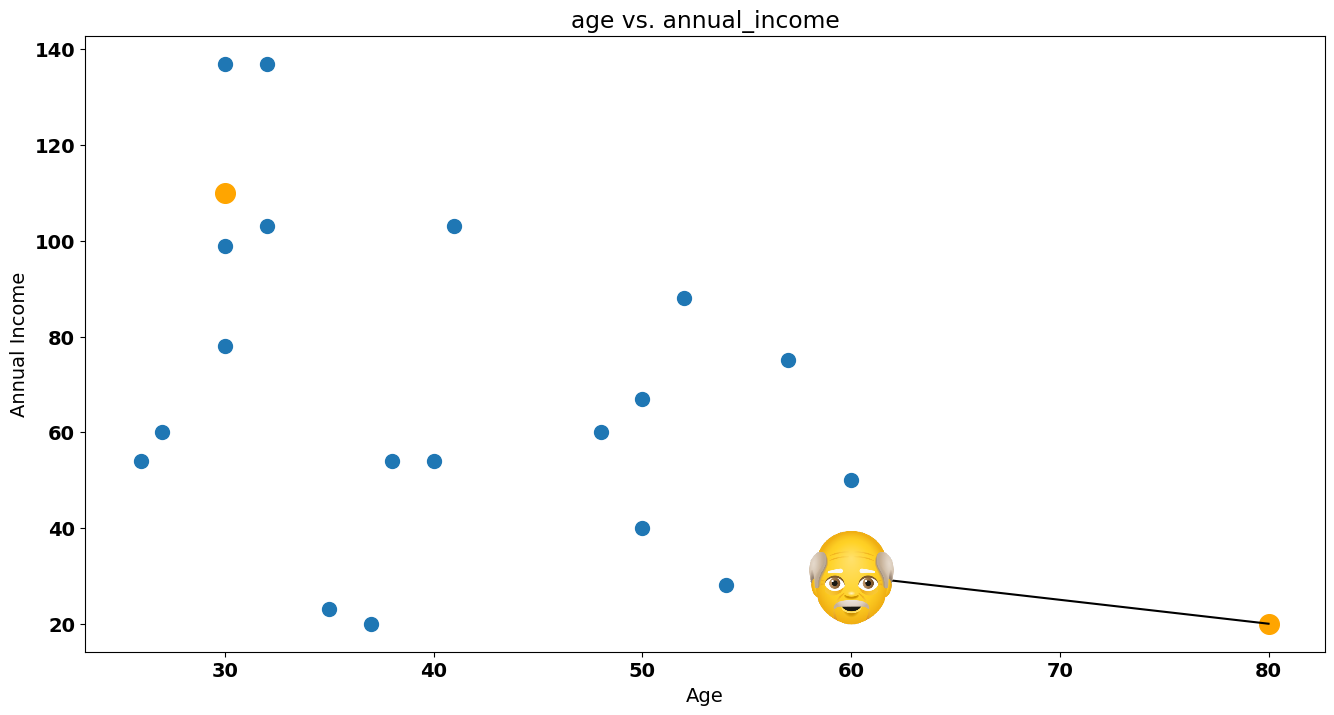

In [7]:
ax = plot_centroids_customers(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]],
    'https://img.icons8.com/emoji/256/old-man-emo.png',
    60,
    30
)

# Adding line to our plot with distance from Steve to the centroid
ax.plot([60, 80], [30, 20], color='black')
plt.show()

Let's calculate the distance between Steve and the centroid using the **euclidean distance**:

In [8]:
math.sqrt((60-80)**2+(30-20)**2)

22.360679774997898

**The euclidean distance between Steve and "centroid 1" is 22.360679.**

What about the distance for centroid 2?

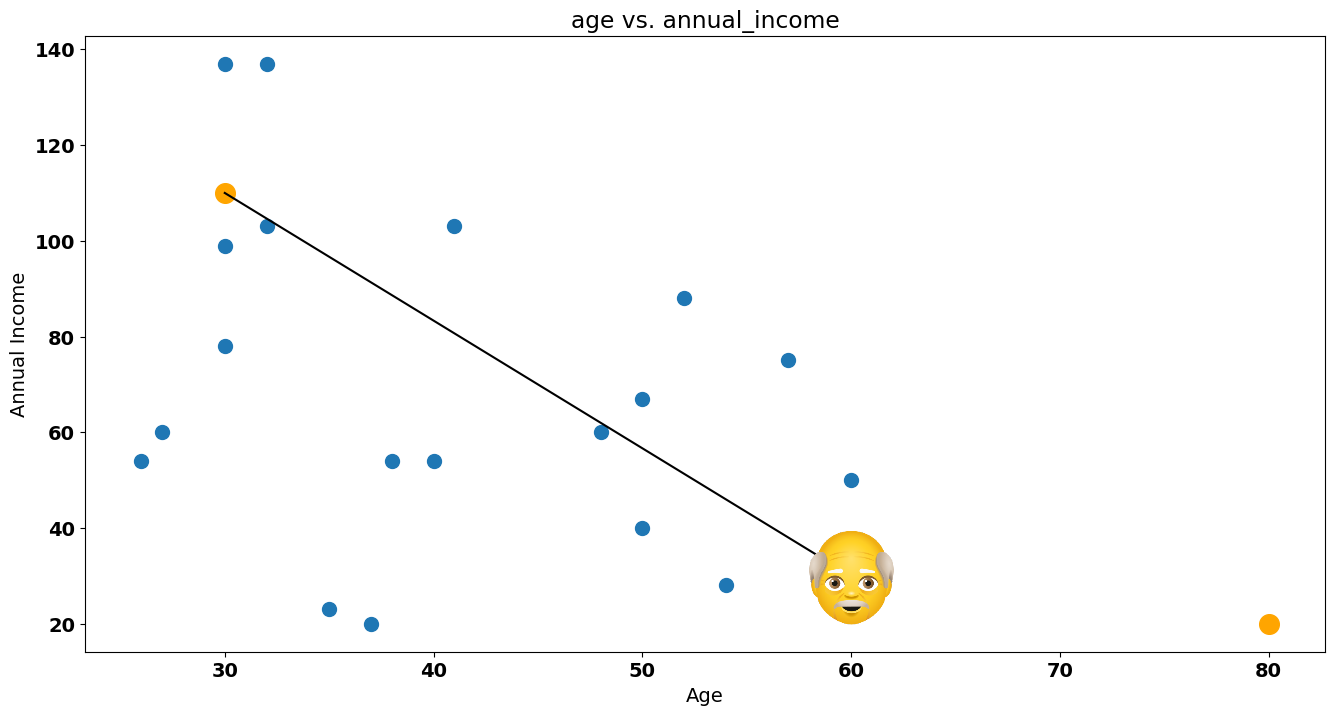

In [9]:
ax = plot_centroids_customers(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]],
    'https://img.icons8.com/emoji/256/old-man-emo.png',
    60,
    30
)

# Adding distance to centroid 2
ax.plot([60, 30], [30, 110], color='black')

In [10]:
# Calculating the euclidean distance for Cluster 2
math.sqrt((60-30)**2+(110-20)**2)

94.86832980505137

Steve is closer to centroid of cluster 1, so he will get assigned to that one - let's mark his scatter with the `red` color:

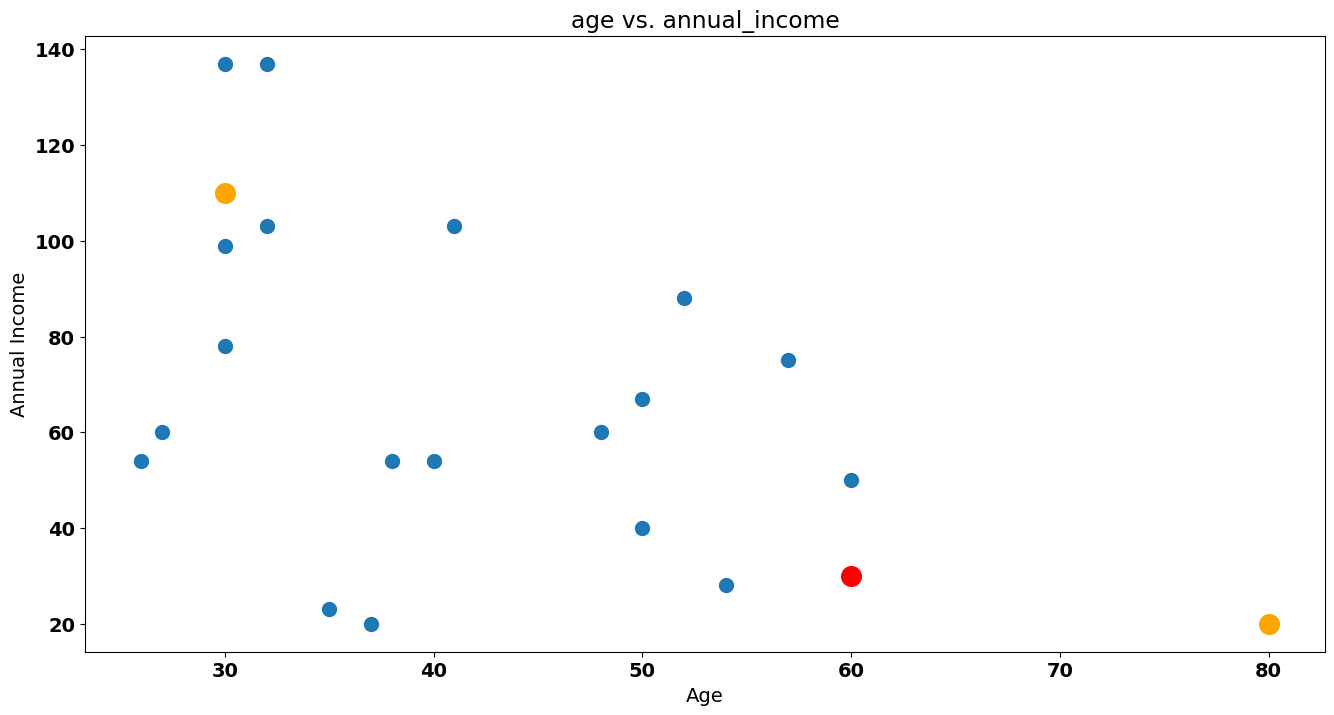

In [11]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]]
  )

plt.scatter(60,30, c='red', s=200)
plt.show()

If we repeat the same logic for each of our customers and assign them to the nearest centroid:

In [12]:
# Calculating distances for each data point

# First calculating the distance between each data point
# to cluster 1
customer_sample['dist_clust_1'] = (
    np.sqrt((customer_sample.age-80)**2+(customer_sample.annual_income-20)**2)
)

# Then doing the same but this time calculating the distance to cluster 2
customer_sample['dist_clust_2'] = (
    np.sqrt((customer_sample.age-30)**2+(customer_sample.annual_income-110)**2)
)

In [13]:
# Assign color to nearest cluster
customer_sample['cluster_color'] = np.where(
    customer_sample.dist_clust_1 < customer_sample.dist_clust_2,
    'red',
    'green'
)

Let's see our `customer_sample` dataframe below:

In [14]:
customer_sample

,customer_id,age,annual_income,average_spending,dist_clust_1,dist_clust_2,cluster_color
72,73,60,50,49,36.055513,67.082039,red
30,31,60,30,4,22.360680,85.440037,red
188,189,41,103,17,91.706052,13.038405,green
77,78,40,54,48,52.497619,56.885851,red
14,15,37,20,13,43.000000,90.271812,red
119,120,50,67,57,55.758407,47.423623,green
97,98,27,60,50,66.400301,50.089919,green
19,20,35,23,98,45.099889,87.143560,red
198,199,32,137,18,126.463433,27.073973,green
174,175,52,88,13,73.539105,31.112698,green


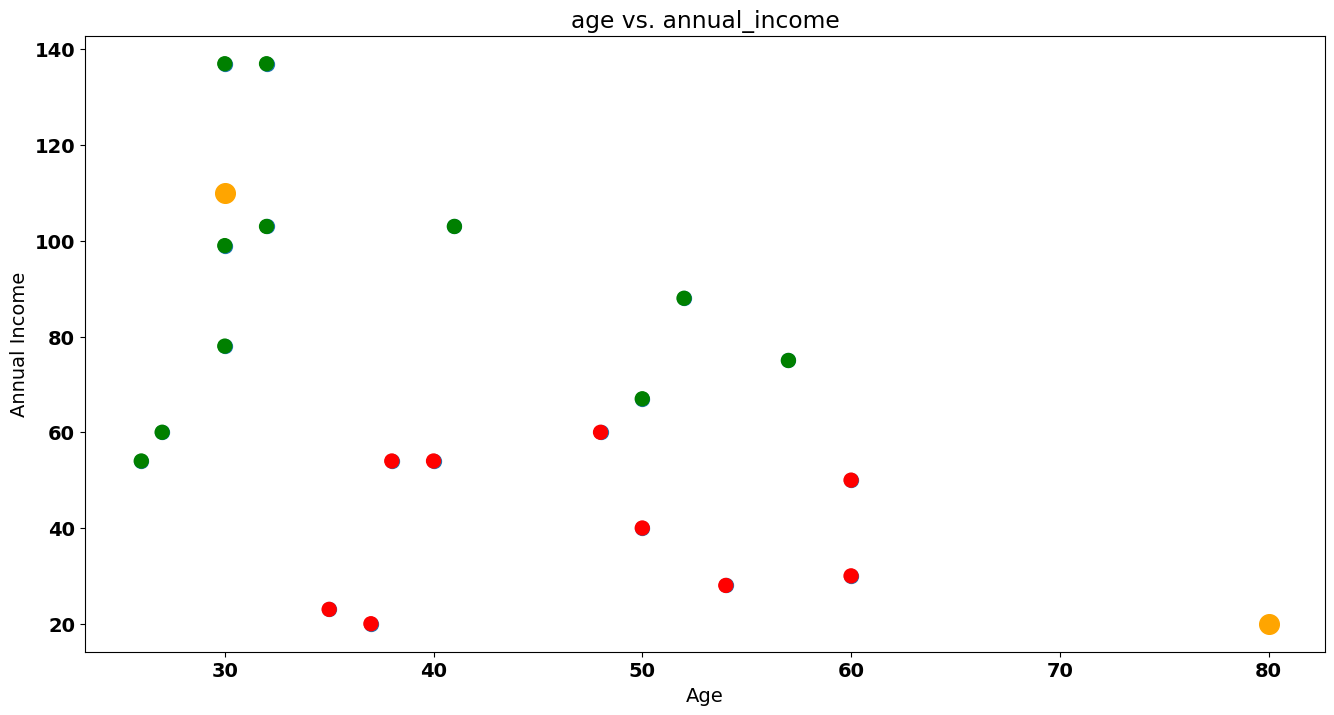

In [15]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]]
  )

plot_clusters(customer_sample, 'cluster_color')

This will make more sense, if we scale the limits of the plot to be the same:

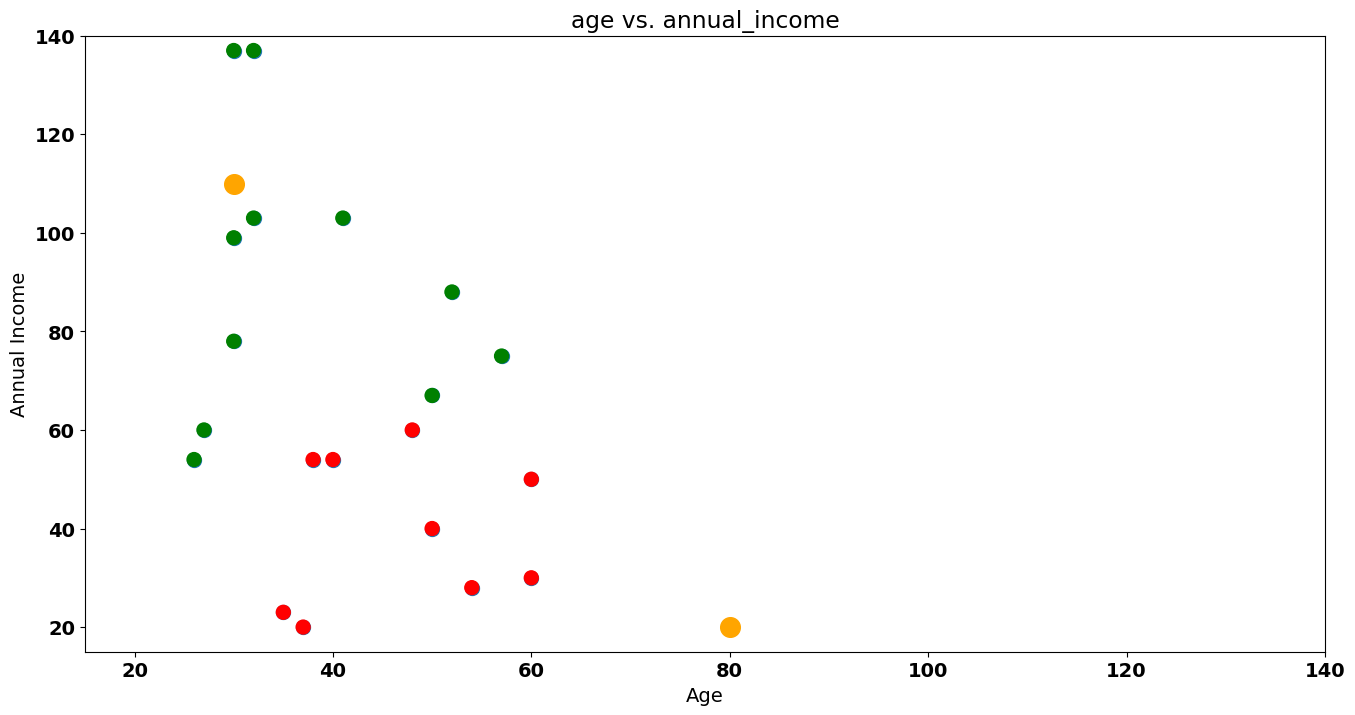

In [16]:

plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]]
  )

plot_clusters(customer_sample, 'cluster_color', norm_limit=True)

Now the magic starts to happen - is this our final clustering solution?
<br>
<br>
No! We want to create the most **similar** groups as possible. We can probably continue to tweak our solution.
<br>
<br>
The **k-means algorithm** does that for us! In the next iteration, the centroids will be recalculated based on the average of the customers assigned to them.
<br>
<br>
The new centroids will be:

In [17]:
customer_sample.groupby(['cluster_color'])[['age', 'annual_income']].mean()

,age,annual_income
cluster_color,,
green,37.000000,91.000000
red,46.888889,39.888889


Let's see our centroids moving:

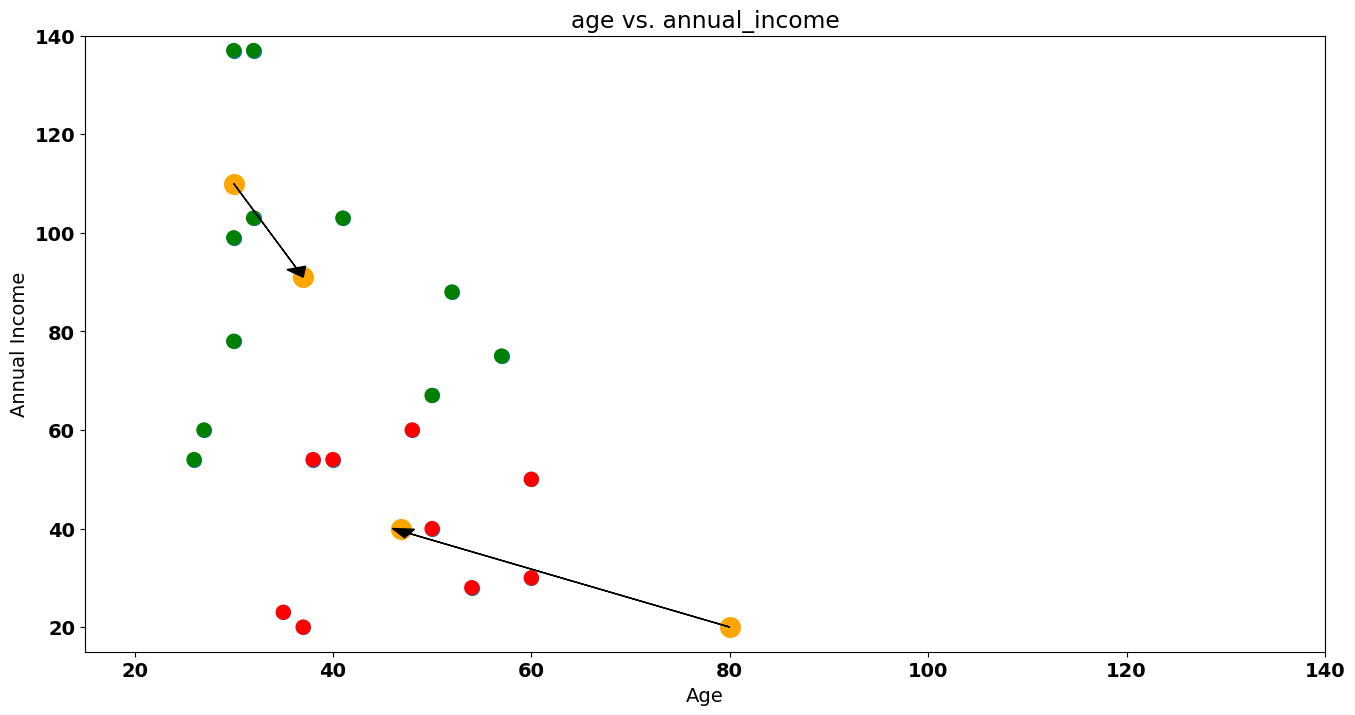

In [18]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[30, 110], [80, 20]]
  )

plot_clusters(customer_sample, 'cluster_color', norm_limit=True)

# Let's plot the new centroids and define an arrow that shows
# how our centroids moved
plt.scatter([37, 46.888], [91, 39.8888], s=200, c='orange')
plt.arrow(30, 110, 7, -19,
          head_width=2, head_length=2, length_includes_head=True, color='black')
plt.arrow(80, 20, -34, 20,
          head_width=2, head_length=2, length_includes_head=True, color='black')
plt.show()

The other centroids go away and they are replaced by the new ones!

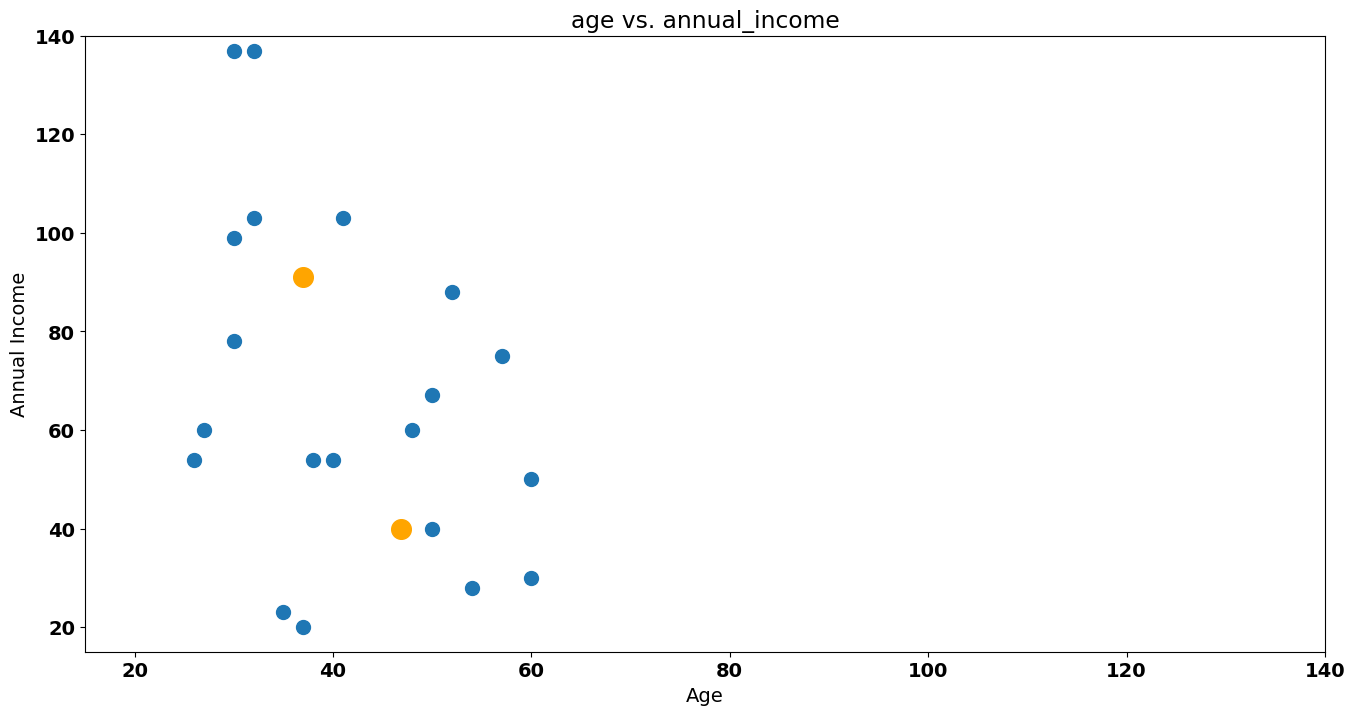

In [19]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[37, 91], [46.8889, 39.8889]]
  )

plt.xlim(15, 140)
plt.ylim(15, 140)
plt.show()

Let's re-calculate the cluster allocation, again - naming it with the suffix `2nditer`:

In [20]:
customer_sample['dist_clust_1_2nditer'] = (
    np.sqrt((customer_sample.age-46.8889)**2
            +(customer_sample.annual_income-39.8889)**2
            )
)

customer_sample['dist_clust_2_2nditer'] = (
    np.sqrt(
        (customer_sample.age-37)**2+(customer_sample.annual_income-91)**2
        )
)

# Assign color to nearest cluster
customer_sample['cluster_color_2nditer'] = np.where(
    customer_sample.dist_clust_1_2nditer
    <
    customer_sample.dist_clust_2_2nditer,
    'red',
    'green'
)

How many customers move to another cluster on this iteration?

In [21]:
moved = customer_sample.loc[customer_sample.cluster_color_2nditer != customer_sample.cluster_color]
moved

,customer_id,age,annual_income,average_spending,dist_clust_1,dist_clust_2,cluster_color,dist_clust_1_2nditer,dist_clust_2_2nditer,cluster_color_2nditer
119,120,50,67,57,55.758407,47.423623,green,27.289021,27.294688,red
97,98,27,60,50,66.400301,50.089919,green,28.284708,32.572995,red
75,76,26,54,54,63.812225,56.142675,green,25.208516,38.600518,red


Let's visualize them, they are the scatters in purple:

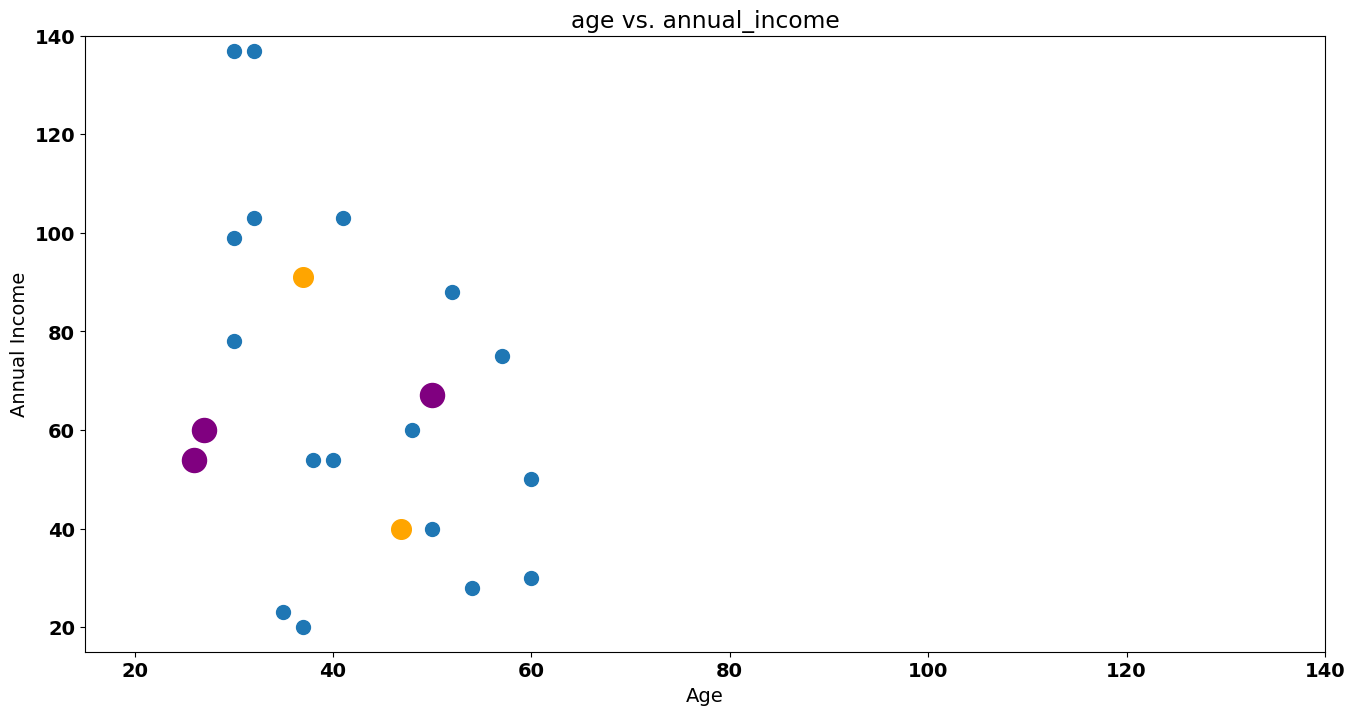

In [22]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[37, 91], [46.8889, 39.8889]]
  )

plt.xlim(15, 140)
plt.ylim(15, 140)

plt.scatter(moved.age, moved.annual_income, c='purple', s=300)
plt.show()

The purple points are the ones that moved from one cluster to the other, when we re-calibrated the centroids.
<br>
<br>
We can view the 2nd iteration of `k-means`:

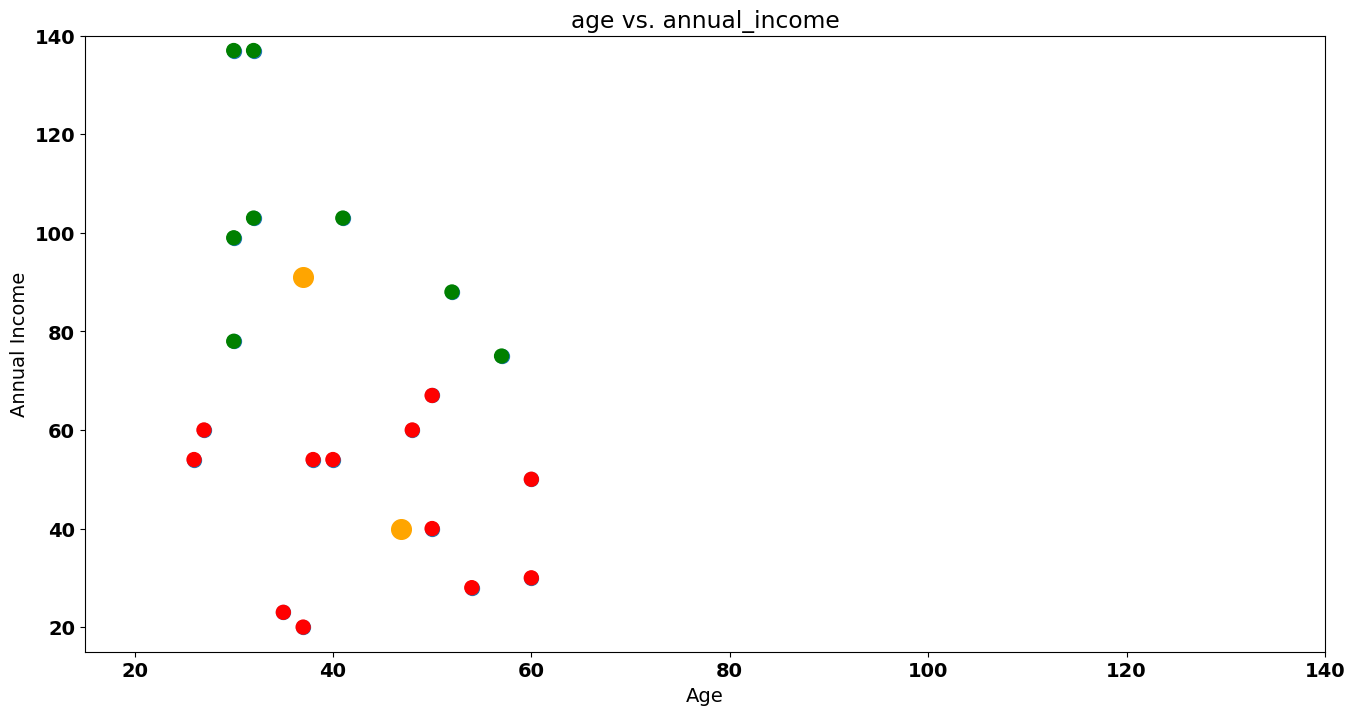

In [23]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[37, 91], [46.8889, 39.8889]]
  )

plot_clusters(customer_sample, 'cluster_color_2nditer', norm_limit=True)

This will go on, iteratively, until no data point is changed between iterations!
<br>
<br>Let's see what clusters are given by the `scikit learn` implementation:

In [24]:
# Fitting a KMeans algorithm with 2 centroids and random state=0
kmeans = KMeans(n_clusters=2, random_state=0)

# Fitting the kmeans object to our data
kmeans.fit(customer_sample[['age','annual_income']])

# Predicting the clusters of our data point.
# In alternative, we coulda lso use fit_predict directly
clusters = kmeans.predict(customer_sample[['age','annual_income']])

# Creating a color code to plot with our plot_clusters function
customer_sample['clusters_opt_solution'] = np.where(
    clusters == 1, 'green','red'
    )

We can get the centroids from the `sklearn` implementation using `cluster_centers_`:

In [25]:
sklearn_centroids = kmeans.cluster_centers_
sklearn_centroids

array([[ 35.28571429, 106.42857143],
       [ 44.76923077,  47.30769231]])

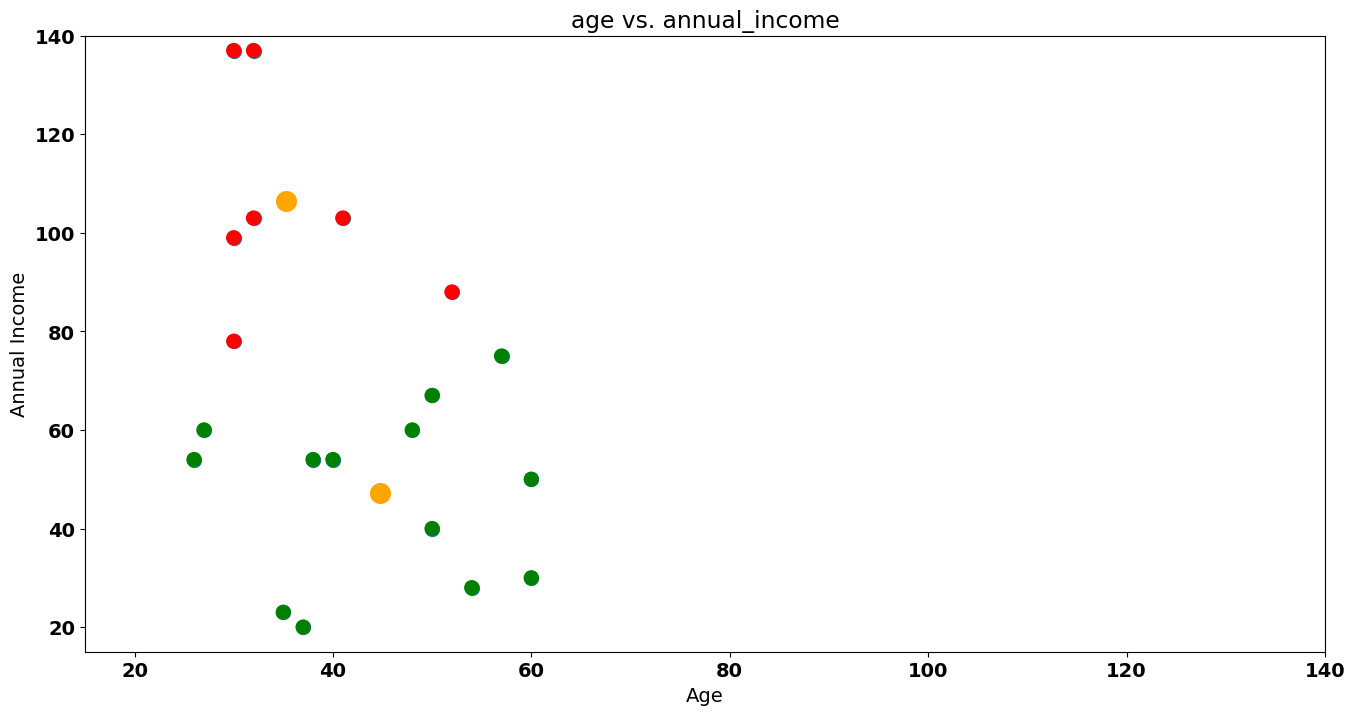

In [26]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Age',
    'Annual Income',
    [[44.76923077, 47.30769231], [35.28571429, 106.42857143]]
  )

plot_clusters(customer_sample, 'clusters_opt_solution', norm_limit=True)

Several things to watch out in `k-means`:
- May take a while to converge! Kmeans ++ is a good way to initialize the algorithm.
- Variables must be scaled so that no variable takes up most of the influence!
- K is an **hyperparameter**! We can use some heuristics to decide K. (we will see this in the last part of the notebook.)

# Hierarchical Clustering - Walkthrough

Hierarchical clustering is a method of cluster analysis which aims to organize the data hierachically.
<br>
In this method, each data point starts in its own cluster and pairs of clusters are merged as one moves up the hierarchy. The result of hierarchical clustering is a **tree-based representation of the objects, called a dendrogram.**
<br>
<br>
There are two antagonic types of hierarchical clustering: agglomerative and divisive. Agglomerative clustering begins with each data point in a separate cluster and combines them into successively larger clusters. Divisive clustering begins with the entire dataset in a single cluster and divides it into smaller clusters.
<br>


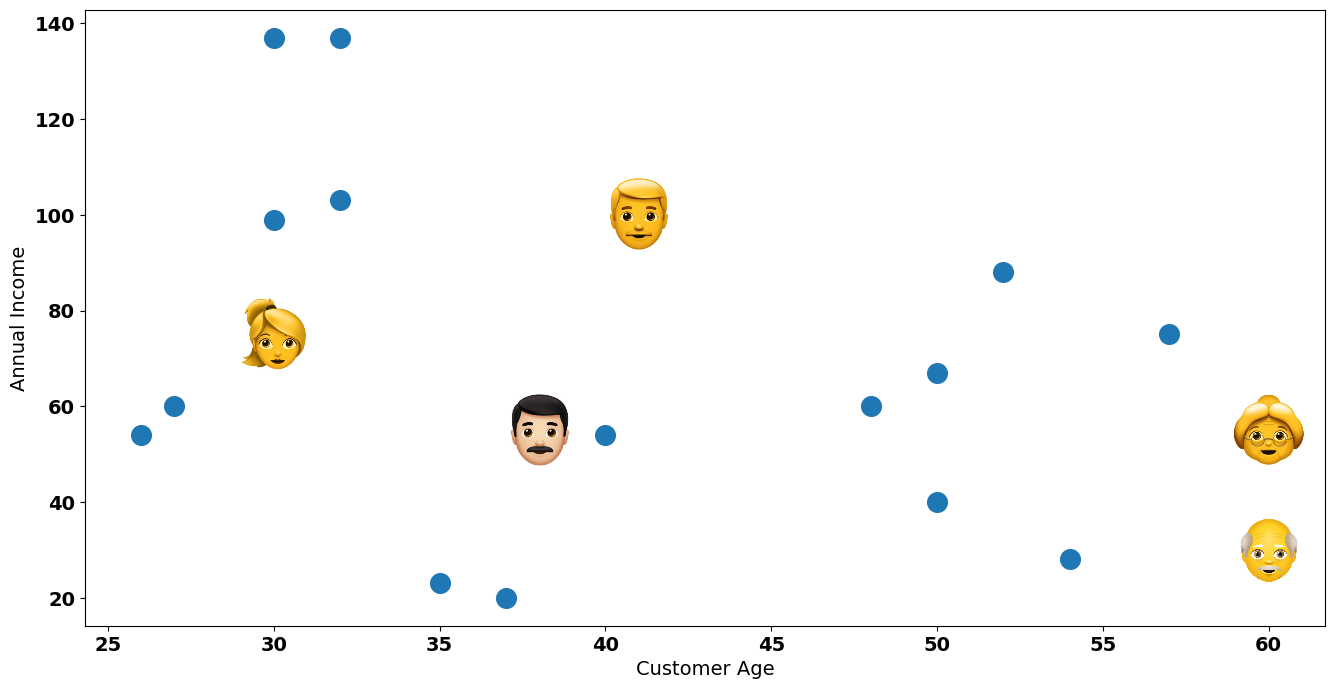

In [27]:
image_data = {
    'https://img.icons8.com/emoji/256/old-man-emo.png': [60,30],
    'http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/old-woman.png': [60,55],
    'http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/blond-haired-woman.png': [30,75],
    'http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/man.png': [41,100],
    'http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/man-light-skin-tone.png': [38,55]
}
plot_customers_hierarchical(customer_sample, image_data)
plt.show()

**One of the simplest ideas to approximate these customers is to check their pairwise distances in our plot.**

For hierarchical clustering, we have two ways of thinking about the problem:
*   Aglomerative approach;
*   Divisive Approach;

And to connect the elements, we can use:
*   Single Linkage (Minimum);
*   Complete Linkage (Maximum);
*   Average Linkage;
*   Centroid Linkage;
*   Ward's Method;

For this step-by-step playbook, we'll see a version of Aglomerative Approach with Centroid Linkage. In the practical examples of the notebook, we'll also look at some of the other methods.
<br>
<br>
Let's start by considering each of our customers as a single "cluster":

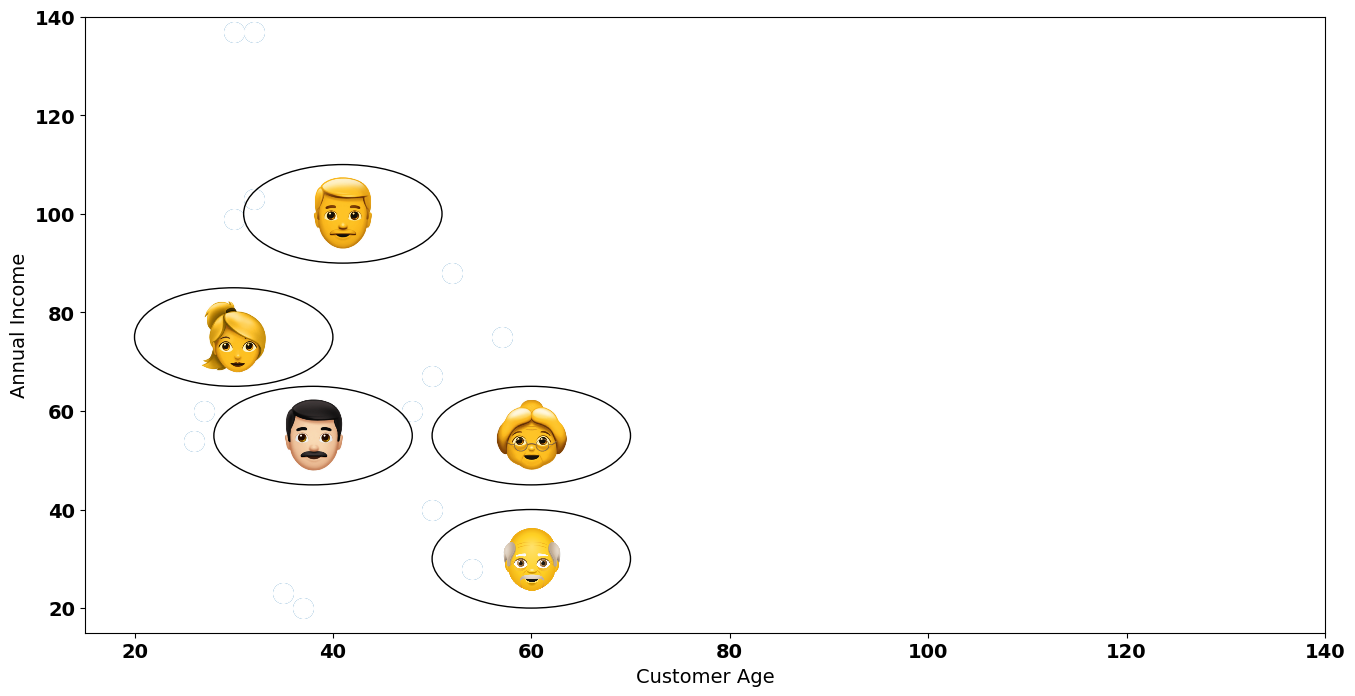

In [28]:
cluster_list = [[60, 30, 10], [60, 55, 10], [30, 75, 10], [41, 100, 10], [38, 55, 10]]
plot_hierarchical_cluster(customer_sample, image_data, cluster_list)

Notice how redoing the scale of the plot changes the perception of the clusters.
<br>
<br>
This is why it is so important to have variables scaled to the same "size" when performing clustering analysis.

Aglomerative clustering is simple - first, we start by treating each data point as it's own cluster - in this case, we would have 5 clusters. We calculate the distance between all the data points above:

In [29]:
# Calculate pairwise distances between data points
objects = [[60, 30], [60, 55], [30, 75], [41, 100], [38, 55]]

for i in range(len(objects)):
  for j in range(i+1, len(objects)):
    print(f"Distance between {objects[i]} and {objects[j]}: {pairwise_euclidean_distances(objects[i], objects[j])}")

Distance between [60, 30] and [60, 55]: 25.0
Distance between [60, 30] and [30, 75]: 54.08326913195984
Distance between [60, 30] and [41, 100]: 72.53275122315436
Distance between [60, 30] and [38, 55]: 33.301651610693426
Distance between [60, 55] and [30, 75]: 36.05551275463989
Distance between [60, 55] and [41, 100]: 48.84669896727925
Distance between [60, 55] and [38, 55]: 22.0
Distance between [30, 75] and [41, 100]: 27.313000567495326
Distance between [30, 75] and [38, 55]: 21.540659228538015
Distance between [41, 100] and [38, 55]: 45.09988913511872


Minimum distance is between points: **[30, 75]** and **[38, 55]**.
<br>
<br>
What do we do? We consider those data points as a single cluster, losing variability - producing a centroid **[34, 65]** (the average between x's and y's of the two data points):

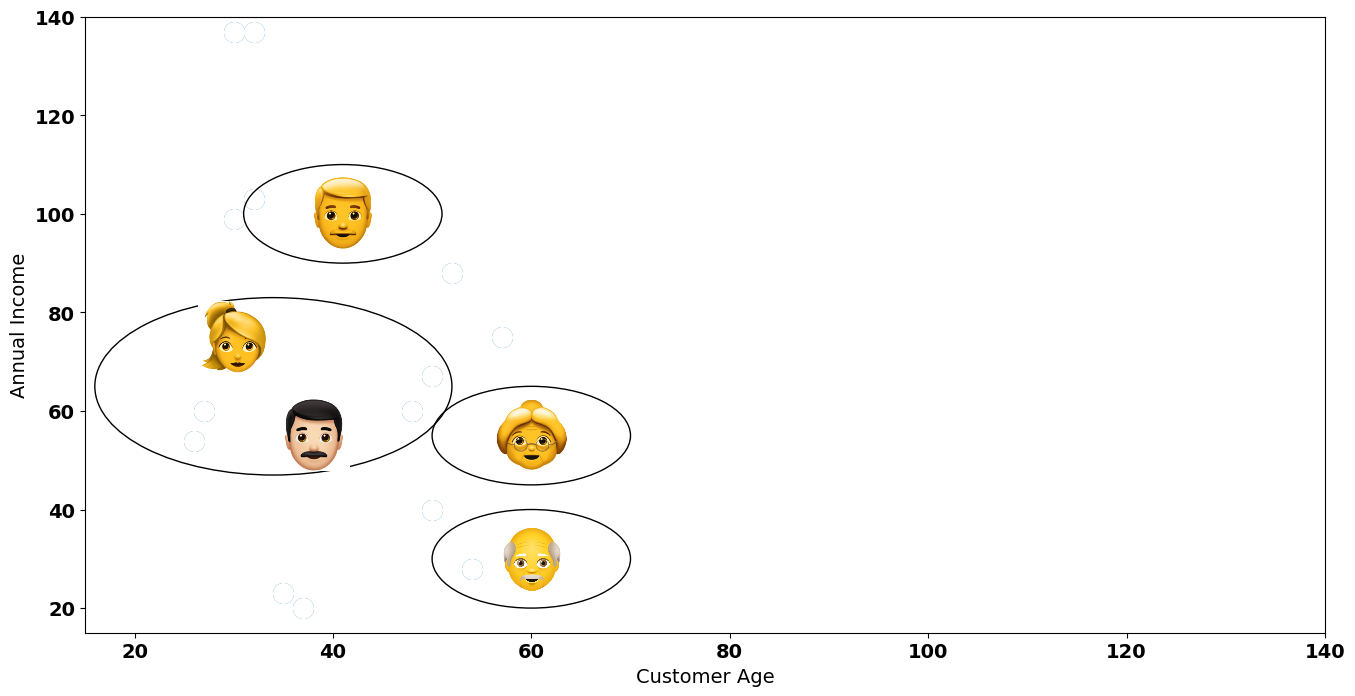

In [30]:
circle_list = [[60, 30, 10], [60, 55, 10], [34, 65, 18], [41, 100, 10]]

plot_hierarchical_cluster(customer_sample, image_data, circle_list)

We now check the distances again:

In [31]:
objects = [[60, 30], [60, 55], [34, 65], [41, 100]]

for i in range(len(objects)):
  for j in range(i+1, len(objects)):
    print(f"Distance between {objects[i]} and {objects[j]}: {pairwise_euclidean_distances(objects[i], objects[j])}")

Distance between [60, 30] and [60, 55]: 25.0
Distance between [60, 30] and [34, 65]: 43.60045871318328
Distance between [60, 30] and [41, 100]: 72.53275122315436
Distance between [60, 55] and [34, 65]: 27.85677655436824
Distance between [60, 55] and [41, 100]: 48.84669896727925
Distance between [34, 65] and [41, 100]: 35.6931365951495


Next in line are points [60, 55] and [60, 30] that will be combined into a new centroid [60, 42.5]:

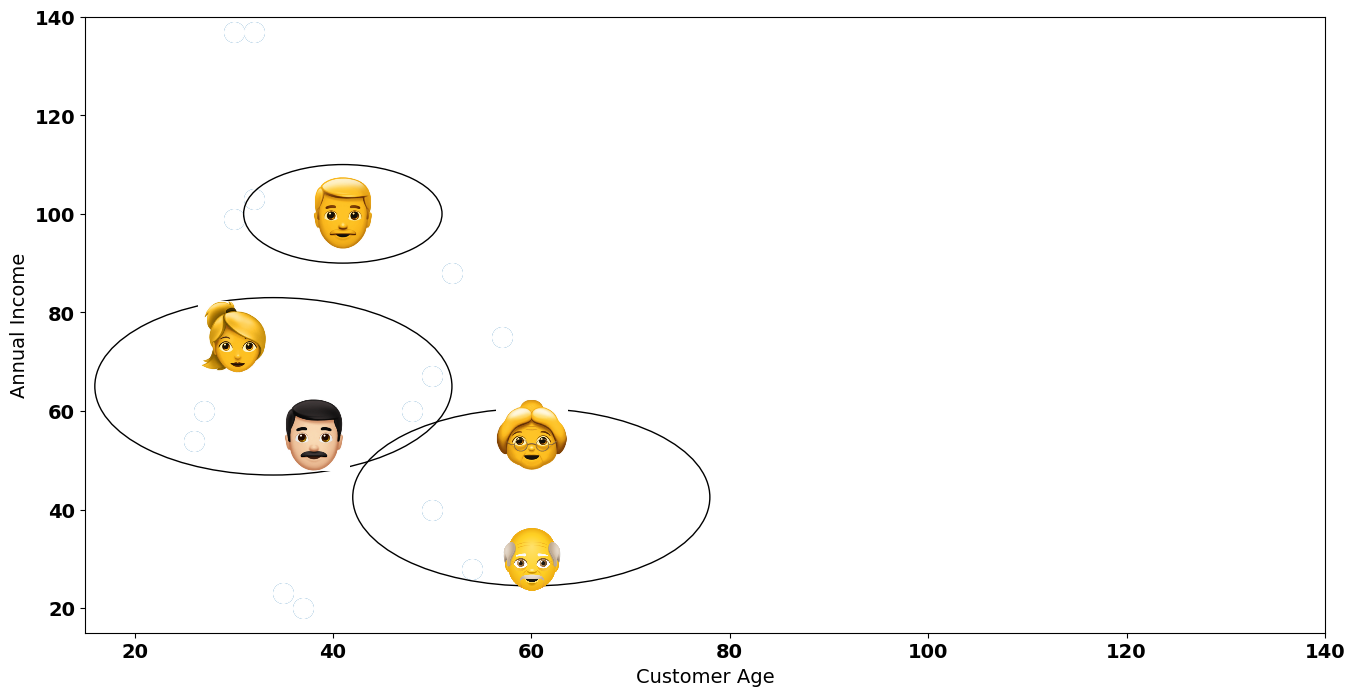

In [32]:
circle_list = [[60, 42.5, 18], [34, 65, 18], [41, 100, 10]]

plot_hierarchical_cluster(customer_sample, image_data, circle_list)

In [33]:
objects = [[60, 42.5], [34, 65], [41, 100]]

for i in range(len(objects)):
  for j in range(i+1, len(objects)):
    print(f"Distance between {objects[i]} and {objects[j]}: {pairwise_euclidean_distances(objects[i], objects[j])}")

Distance between [60, 42.5] and [34, 65]: 34.38386249390839
Distance between [60, 42.5] and [41, 100]: 60.55782360686355
Distance between [34, 65] and [41, 100]: 35.6931365951495


Next, we join the two big clusters:

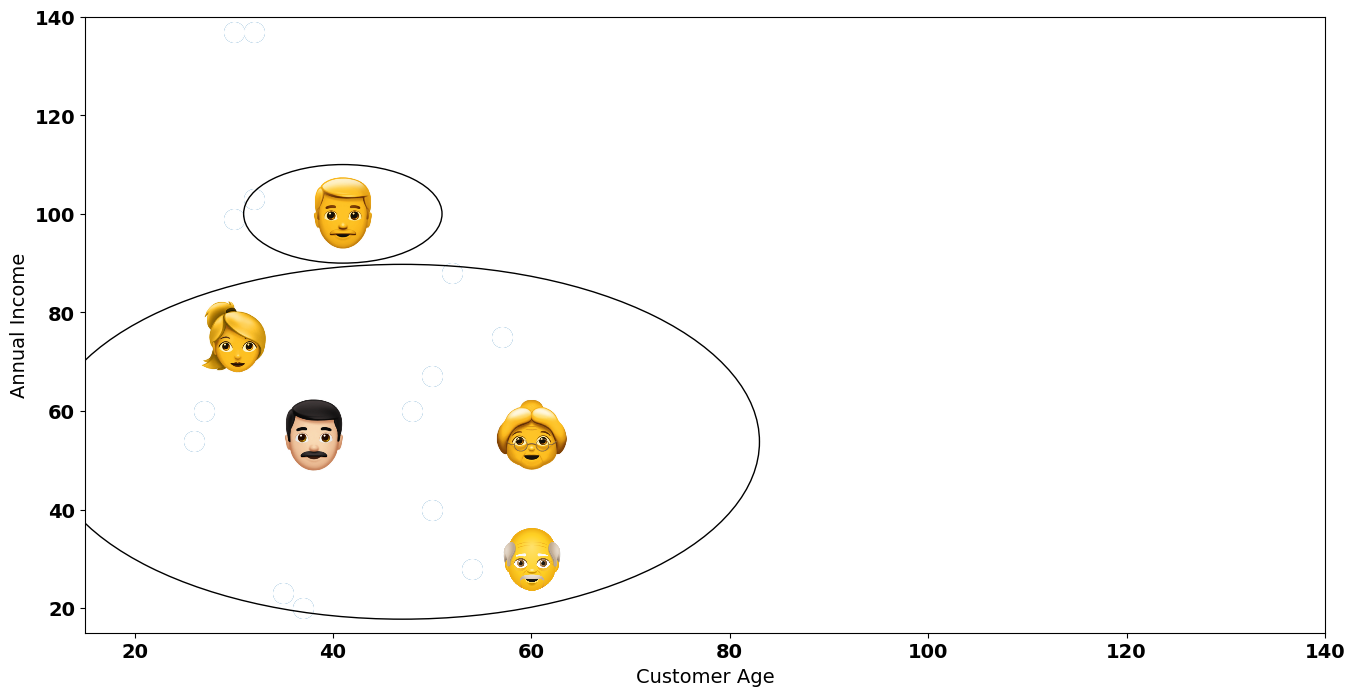

In [34]:
circle_list = [[47, 53.75, 36], [41, 100, 10]]
plot_hierarchical_cluster(customer_sample, image_data, circle_list)

Naturally, the next step is to join all customers together into a single cluster! (although this doesn't bring that much value, though)...

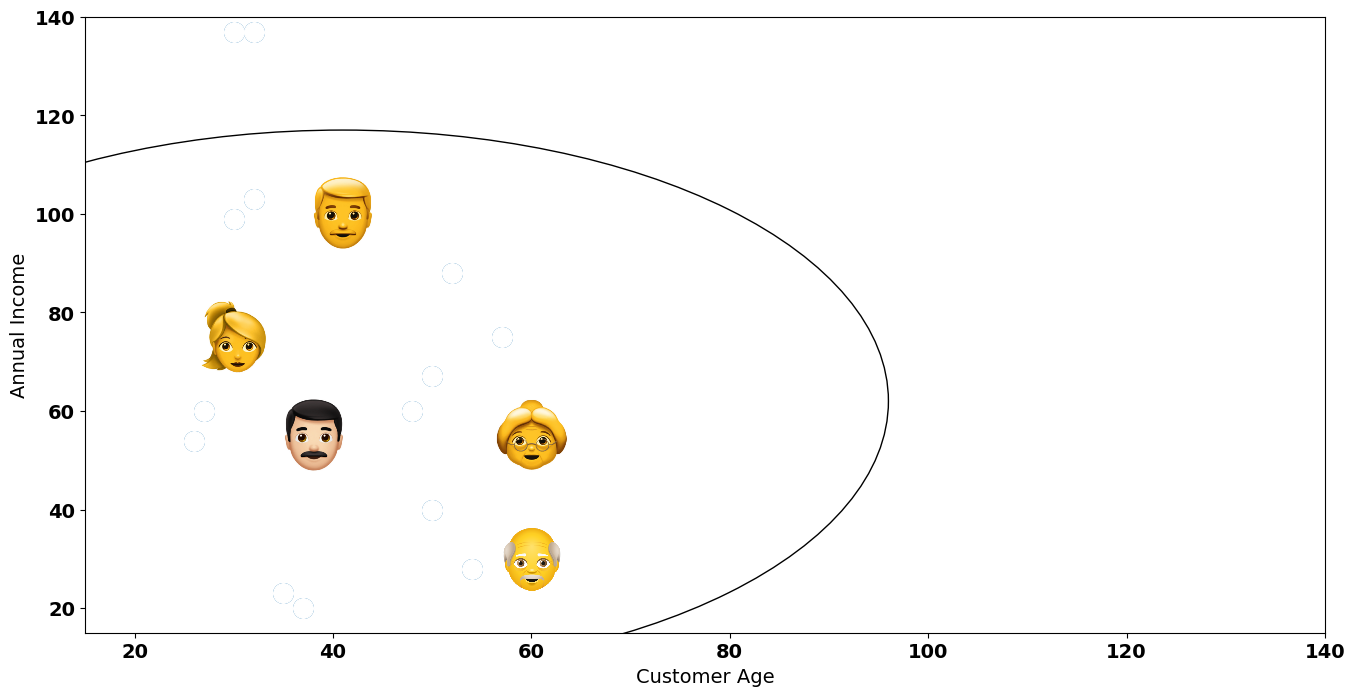

In [35]:
circle_list = [[41, 62, 55]]
plot_hierarchical_cluster(customer_sample, image_data, circle_list)

If we think about this plot in a **Dendogram** format, we can produce an aglomerative plot that would give us fresh new way to look into this data:

In [36]:
# let's just build an example frame with our five customers.
customer_5_list = [[60, 30], [60, 55], [30, 75], [41, 100], [38, 55]]

example_frame = pd.DataFrame(
    customer_5_list,
    columns = ['age','income']
)

In [37]:
# First time we're seeing the sklearn implementation!
clustering = (
    AgglomerativeClustering(distance_threshold=0, n_clusters=None)
    .fit(example_frame[['age','income']])
)

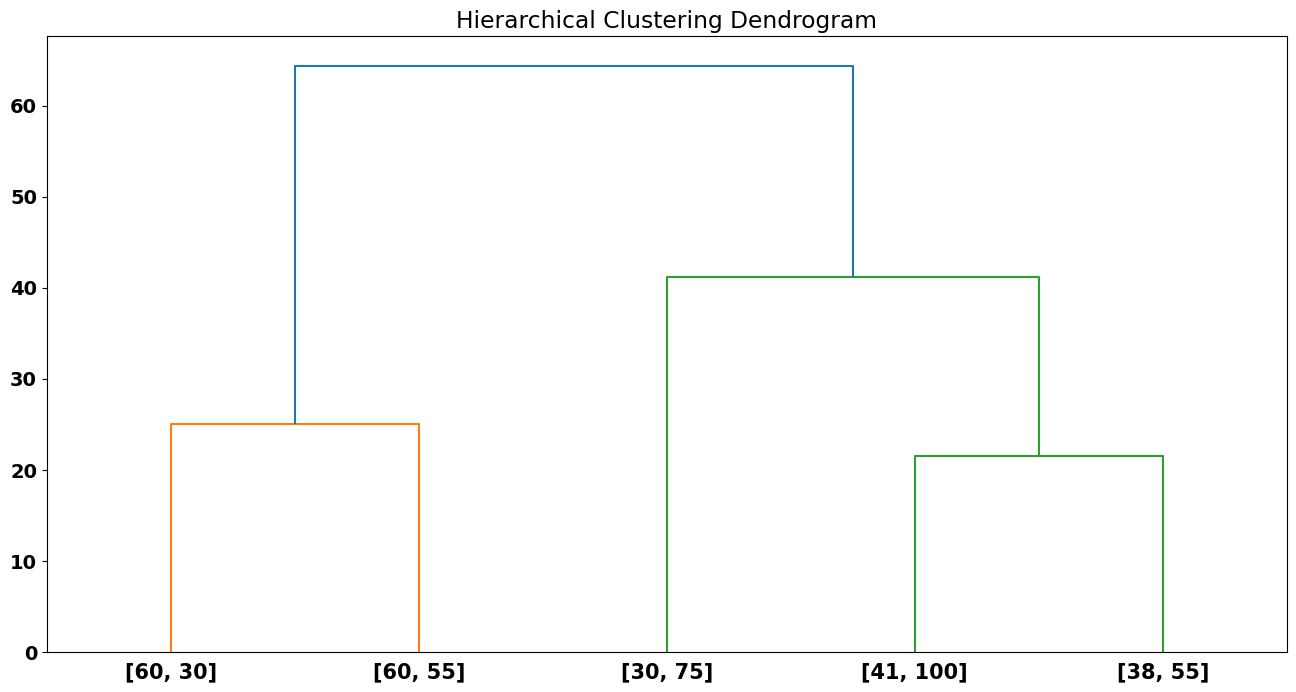

In [38]:
# Plot our Dendrogram view

fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(clustering, truncate_mode="level", p=3)
ax.set_xticklabels(customer_5_list, rotation=0, fontsize=15)
plt.show()

# A Real Life scenario example!

In this part of the notebook, we are going to do a small clustering project  similar to a real life project that companies also employ.

Our use case is simple - we are going to build a segmentation for our retail customers. The company wants to spend some money on target ads and wants to understand what segments it should target.

In [ ]:
customer_data = pd.read_csv('/content/data/marketing_campaign.csv', sep='\t')

In [ ]:
customer_data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,44
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0,58
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0,54
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0,40
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1,51
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0,75


In [ ]:
# Calculate Age of Customer
customer_data['Age'] = (
    datetime.date.today().year-customer_data['Year_Birth']
)

# Dummify Education variable
education = pd.get_dummies(customer_data.Education)

In [ ]:
# Build X-train

x_train = pd.concat([
    customer_data[['Recency', 'MntWines', 'MntFruits',
    'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
    'MntGoldProds','Age']],
    education],
    axis=1
)

# Drop the Absurd column
x_train = x_train.loc[:, ~x_train.columns.isin(['Absurd'])]

In [ ]:
education

,2n Cycle,Basic,Graduation,Master,PhD
0,False,False,True,False,False
1,False,False,True,False,False
2,False,False,True,False,False
3,False,False,True,False,False
4,False,False,False,False,True
...,...,...,...,...,...
2235,False,False,True,False,False
2236,False,False,False,False,True
2237,False,False,True,False,False
2238,False,False,False,True,False


Let's start by scalling the data using `standardization`:

In [ ]:
scaler = StandardScaler()
# Here, we are using fit_transform, by fitting and
# immediately transforming the data into the scaled values
scaled_data = scaler.fit_transform(x_train)



Now, let's perform a K-means Clustering - how do we choose the number of clusters? This will be the first time where we are going to see the **elbow curve**.
<br>
<br>
The idea is simple: we perform the clustering for several different `k's`and see where adding an extra cluster will not add that much value - the "much value" is shown by `inertia`, an attribute that states how much information we loose by combining data points.

In [ ]:
dispersion = []
for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(scaled_data)
    dispersion.append(kmeans.inertia_)

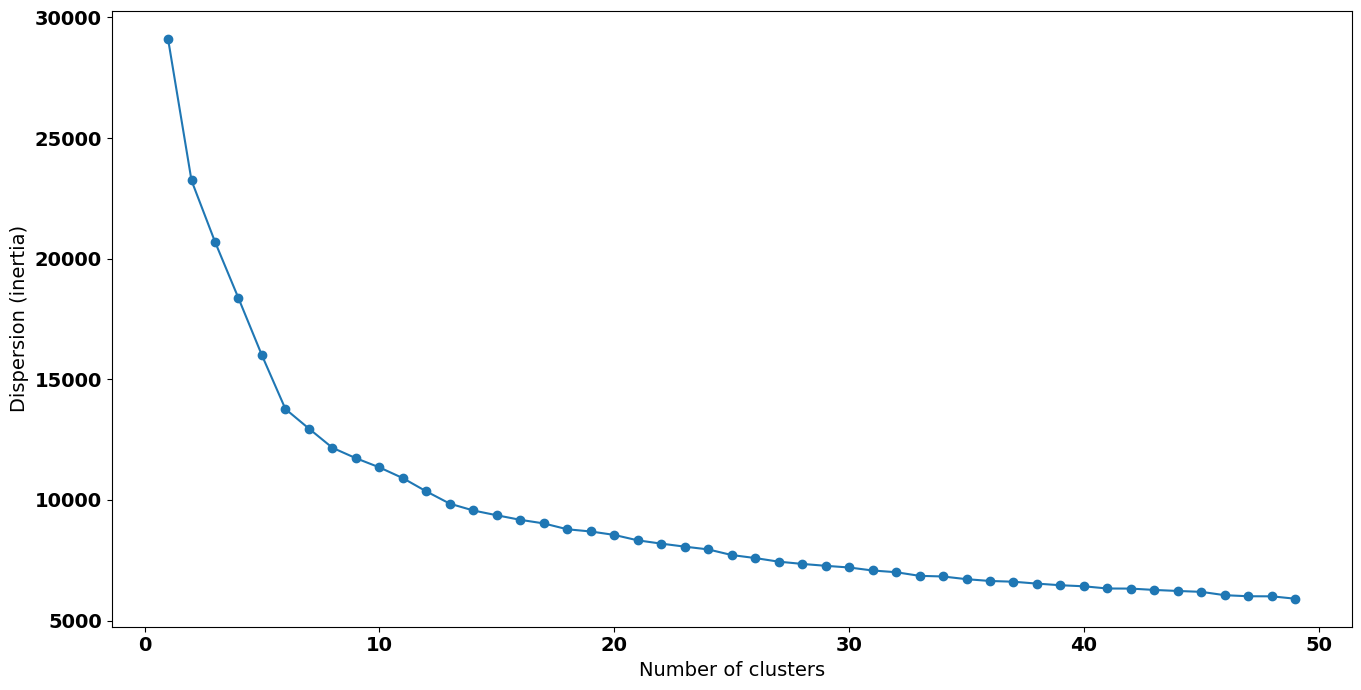

In [ ]:
plt.plot(range(1, 50), dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

Two potential cut points that we see on the elbow curve above:

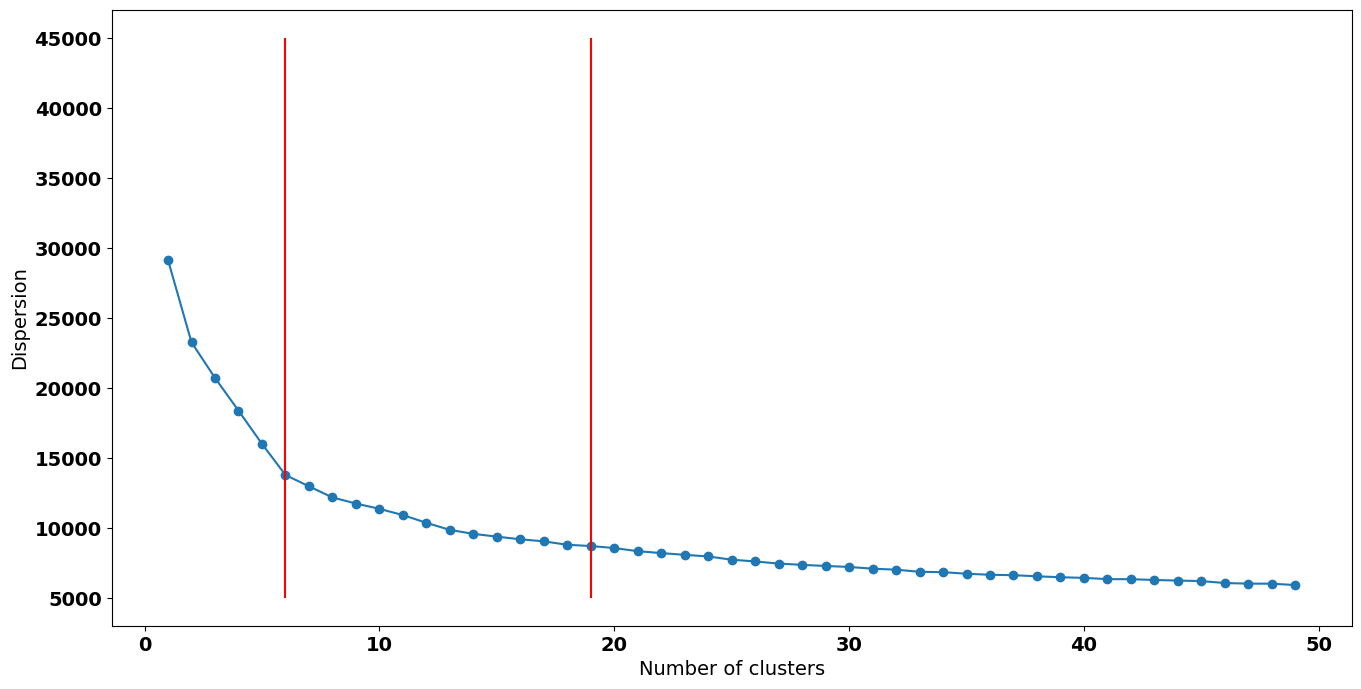

In [ ]:
# Plotting inertia with cutoff points

plt.plot(range(1, 50), dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion')
plt.vlines(6, 5000, 45000, color='red')
plt.vlines(19, 5000, 45000, color='red')
plt.show()

These two points have two different arguments to be chosen:
- 6 is the first point where the slope of this plot decreases in terms of absolute value. Using this cutoff will give us a better interpretability of the clusters.
- Around the 19/20 region, adding a new cluster does not bring much information (measured by the dispersion) so we can choose this as a cut-off as well. The main issue is that we will have a hard time interpreting this amount of clusters.

**Dispersion (inertia in the sklearn implementation) is calculated by summing the distances between each point and the centroid!**

Let's interpret the clustering solution with 6 centroids. How do we interpret these clusters?
<br>
<br>
We can calculate the means of the original variables and compare them against the cluster mean:

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=0).fit(scaled_data)
x_train['cluster_kmeans'] = kmeans.predict(scaled_data)

In [ ]:
x_train.groupby(['cluster_kmeans']).mean()

,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Age,2n Cycle,Basic,Graduation,Master,PhD
cluster_kmeans,,,,,,,,,,,,,
0,47.799392,278.240122,13.197568,112.756839,20.349544,13.079027,34.583587,58.142857,0.000000,0.0,0.00,1.000000,0.000000
1,50.800000,591.597778,79.546667,451.631111,111.913333,82.313333,90.864444,56.668889,0.046667,0.0,0.78,0.091111,0.082222
2,49.185567,159.067010,9.943299,65.306701,14.439433,10.307990,31.698454,54.894330,0.000000,0.0,1.00,0.000000,0.000000
3,48.444444,7.240741,11.111111,11.444444,17.055556,12.111111,22.833333,47.537037,0.000000,1.0,0.00,0.000000,0.000000
4,48.664835,161.241758,20.807692,109.763736,33.692308,22.989011,41.945055,52.598901,1.000000,0.0,0.00,0.000000,0.000000
5,48.503341,378.358575,14.868597,138.895323,19.472160,14.342984,28.679287,59.035635,0.000000,0.0,0.00,0.000000,1.000000


And checking the overall mean:

In [ ]:
x_train.mean()

,0
Recency,49.109375
MntWines,303.935714
MntFruits,26.302232
MntMeatProducts,166.950000
MntFishProducts,37.525446
MntSweetProducts,27.062946
MntGoldProds,44.021875
Age,56.194196
2n Cycle,0.090625
Basic,0.024107


![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

Note: It is **very** important to compare clusters against the mean of the variables and not their relative difference in between clusters. The mean (or any other centrality measure) of the variable will give us an "anchor" that we can use when explaining why a certain "cluster" has a certain set of characteristics.

It is also valuable to check how many customers we have per cluster:

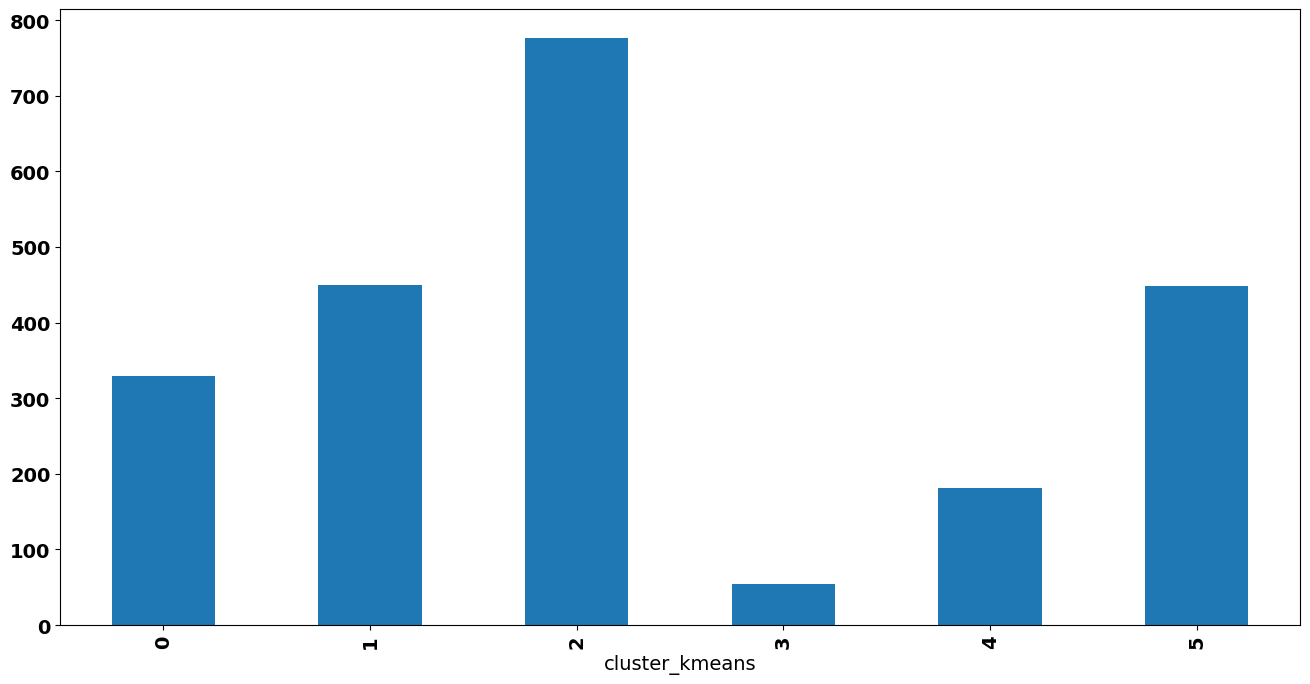

In [ ]:
x_train.groupby(['cluster_kmeans']).size().plot(kind='bar')
plt.show()

Now the question unfolds - will hierarchical clustering give us the same conclusions? Let's see an example of a *single linkage hierachical clustering*:

In [ ]:
minimum_hierarchical = AgglomerativeClustering(
    linkage='single', distance_threshold=0, n_clusters=None
    ).fit(scaled_data)

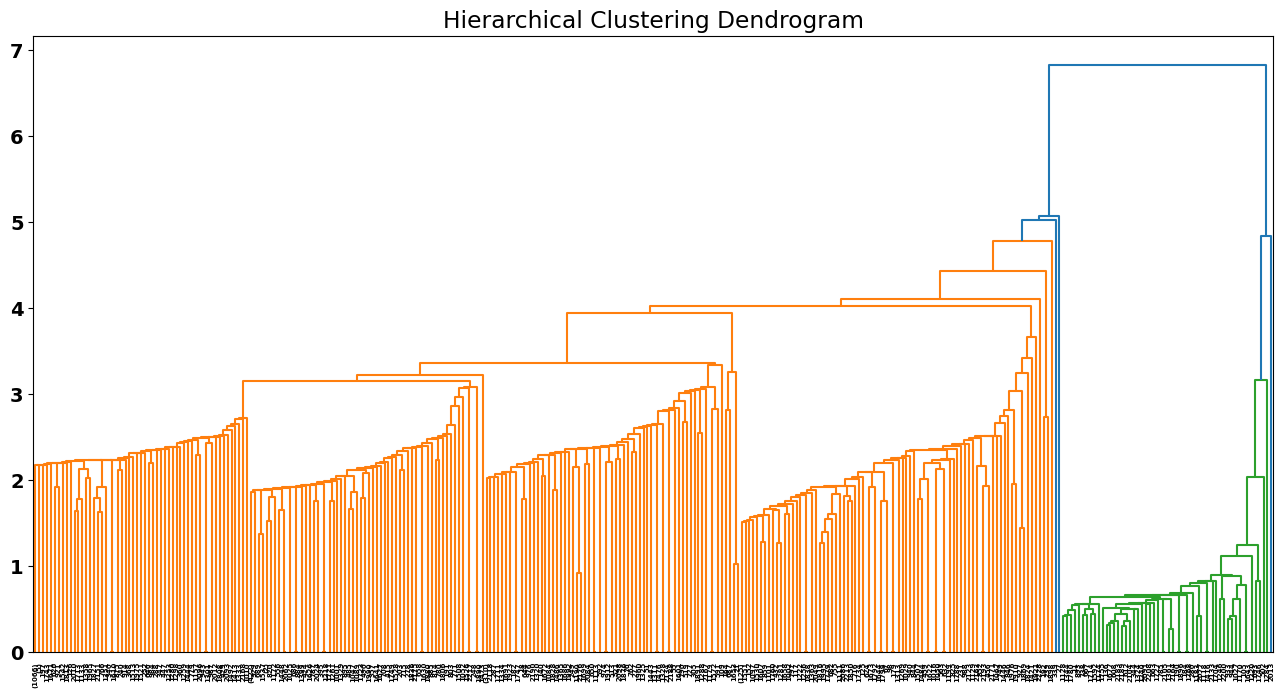

In [ ]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(minimum_hierarchical, truncate_mode="level", p=50)
plt.show()

Single linkage (minimum) tends to form these "chains" of data that may not be appropriate for most use cases.
<br>
<br>
We'll cut the dendrogram at 6 clusters, as from these point onwards, distances to split the data are smaller and smaller.
<br>
<br>
The number of lines that our horizontal line crosses is the number of final clusters in the solution!

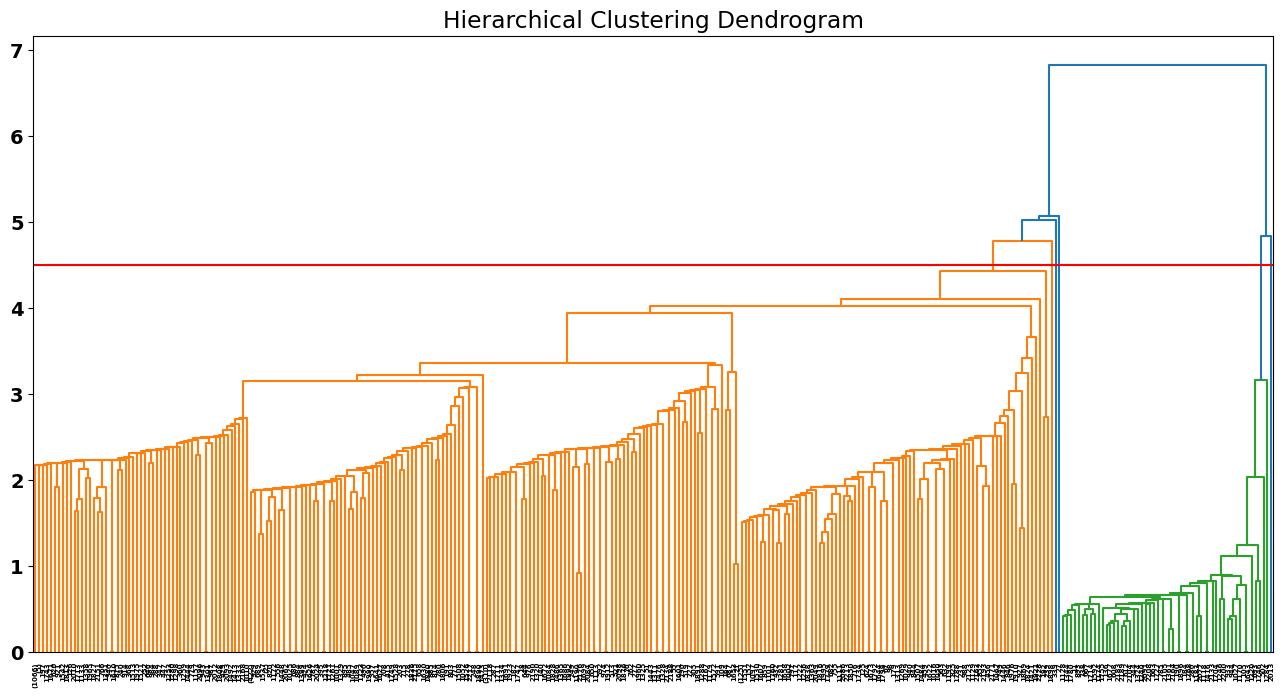

In [ ]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(minimum_hierarchical, truncate_mode="level", p=50)
plt.axhline(y = 4.5, color = 'r', linestyle = '-')
plt.show()

The `"ward"` method dendrogram will have, definitely, another look:

In [ ]:
agg_clust = AgglomerativeClustering(
    linkage='ward', distance_threshold=0, n_clusters=None
    ).fit(scaled_data)

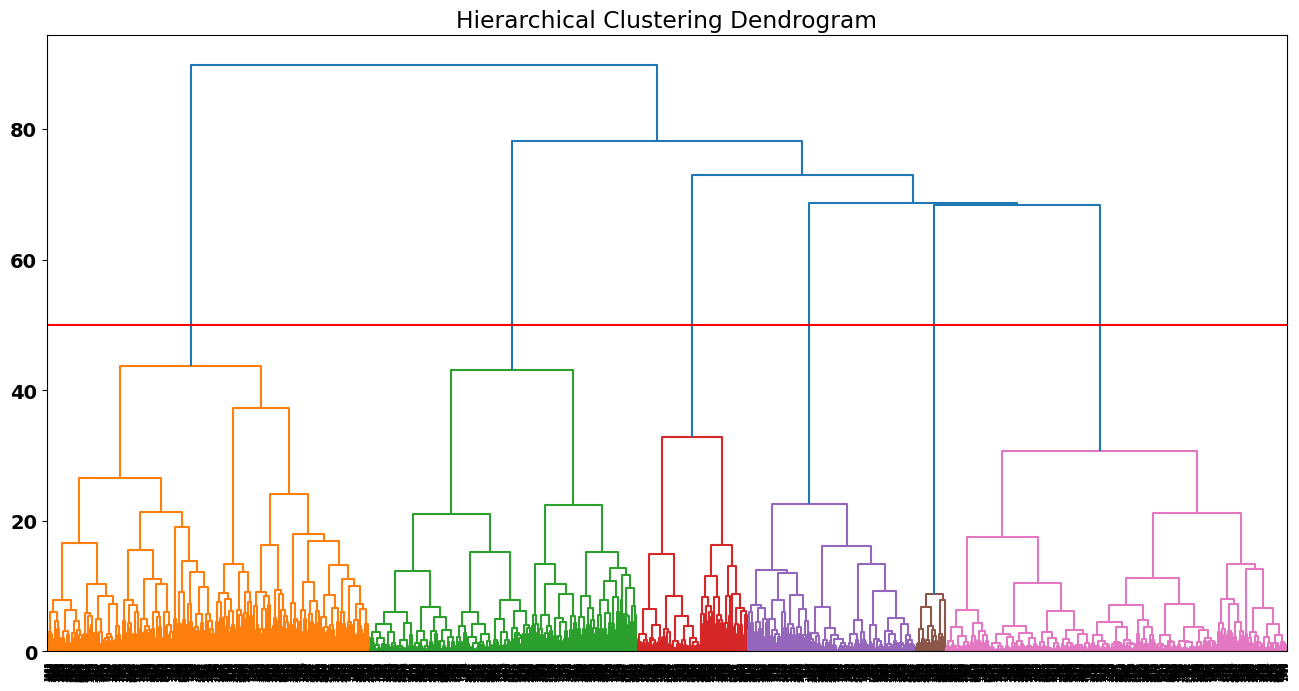

In [ ]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(agg_clust, truncate_mode="level", p=50)
plt.axhline(y = 50, color = 'r', linestyle = '-')
plt.show()

Notice that the `ward` solution tends to have a more "distributed" approach when forming clusters and also build more "spherical" groups, when compared with the `single` method.

Let's compare the three solutions (`k-means` * `ward` * `single`):

In [ ]:
x_train['cluster_ward'] = AgglomerativeClustering(
    linkage='ward', n_clusters=6
    ).fit_predict(scaled_data)
x_train['cluster_single'] = AgglomerativeClustering(
    linkage='single', n_clusters=6
    ).fit_predict(scaled_data)

In [ ]:
x_train.groupby(['cluster_ward']).mean()

,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Age,2n Cycle,Basic,Graduation,Master,PhD,cluster_kmeans,cluster_single
cluster_ward,,,,,,,,,,,,,,,
0,52.001712,539.250000,60.070205,372.085616,84.436644,60.184932,88.106164,56.349315,0.001712,0.0,0.878425,0.114726,0.005137,1.258562,0.011986
1,48.270000,200.880000,29.350000,135.275000,48.065000,34.725000,46.850000,52.250000,1.000000,0.0,0.000000,0.000000,0.000000,3.685000,0.000000
2,48.519669,406.840580,20.132505,163.010352,26.855072,19.795031,32.494824,58.960663,0.000000,0.0,0.000000,0.000000,1.000000,4.693582,0.006211
3,47.615260,90.930195,7.344156,41.344156,11.261364,7.548701,17.813312,55.016234,0.003247,0.0,0.996753,0.000000,0.000000,2.003247,0.000000
4,48.184818,240.297030,10.290429,81.831683,14.204620,12.089109,32.620462,58.026403,0.000000,0.0,0.000000,1.000000,0.000000,0.006601,0.000000
5,48.444444,7.240741,11.111111,11.444444,17.055556,12.111111,22.833333,47.537037,0.000000,1.0,0.000000,0.000000,0.000000,3.000000,1.055556


In [ ]:
x_train.mean()

,0
Recency,49.109375
MntWines,303.935714
MntFruits,26.302232
MntMeatProducts,166.950000
MntFishProducts,37.525446
MntSweetProducts,27.062946
MntGoldProds,44.021875
Age,56.194196
2n Cycle,0.090625
Basic,0.024107


One thing we can do is do a confusion matrix between the `hierarchical` and `k-means` solution:

In [ ]:
# Starting with the Ward vs. k-means:
pd.DataFrame(
    confusion_matrix(x_train.cluster_kmeans, x_train.cluster_ward),
    index = ['K-means {} Cluster'.format(i) for i in np.arange(0,6)],
    columns = ['Ward {} Cluster'.format(i) for i in np.arange(0,6)],
)

,Ward 0 Cluster,Ward 1 Cluster,Ward 2 Cluster,Ward 3 Cluster,Ward 4 Cluster,Ward 5 Cluster
K-means 0 Cluster,28,0,0,0,301,0
K-means 1 Cluster,388,21,37,2,2,0
K-means 2 Cluster,164,0,0,612,0,0
K-means 3 Cluster,0,0,0,0,0,54
K-means 4 Cluster,1,179,0,2,0,0
K-means 5 Cluster,3,0,446,0,0,0


`Ward` and `kmeans` really have similar solutions.
<br>
<br>
Only the first k-means cluster (Younger Graduates cluster is getting divided - we'll see why in a bit!). Also, let's see how divergent *single hierarchical* is from *k-means*:

In [ ]:
# Checking the single Linkage vs. K-Means
pd.DataFrame(
    confusion_matrix(x_train.cluster_kmeans, x_train.cluster_single),
    index = ['K-means {} Cluster'.format(i) for i in np.arange(0,6)],
    columns = ['Single {} Cluster'.format(i) for i in np.arange(0,6)],
)

,Single 0 Cluster,Single 1 Cluster,Single 2 Cluster,Single 3 Cluster,Single 4 Cluster,Single 5 Cluster
K-means 0 Cluster,329,0,0,0,0,0
K-means 1 Cluster,448,0,0,1,0,1
K-means 2 Cluster,776,0,0,0,0,0
K-means 3 Cluster,0,53,0,0,1,0
K-means 4 Cluster,182,0,0,0,0,0
K-means 5 Cluster,448,0,1,0,0,0


What's interesting is that the minimum (single) linkage also identifies the low spenders very well! It's not useful for other clusters, though..

Before we leave for the exercise section, let's just see why our cluster 0 was split in the *ward* solution:

In [ ]:
younger_graduates = x_train.loc[x_train.cluster_kmeans == 2]

In [ ]:
younger_graduates.groupby(['cluster_ward']).size()

,0
cluster_ward,
0,164
3,612


In [ ]:
younger_graduates.groupby(['cluster_ward']).mean()

,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Age,2n Cycle,Basic,Graduation,Master,PhD,cluster_kmeans,cluster_single
cluster_ward,,,,,,,,,,,,,,,
0,54.701220,414.634146,20.195122,157.432927,27.164634,20.908537,84.085366,55.390244,0.0,0.0,1.0,0.0,0.0,2.0,0.0
3,47.707516,90.581699,7.196078,40.619281,11.029412,7.467320,17.660131,54.761438,0.0,0.0,1.0,0.0,0.0,2.0,0.0


Interestingly, these customers were mostly divided by recency and some of these customers actually spend a lot on wine. Although their degree (Graduation) is approximating them, there are other underlying patterns that we may need to take care of. **Be mindful that binary columns - even when they are standardized - can have a big influence on the clustering algorithm, due to their low variability - they should be introduced with care in the clustering.**
<br>
<br>
Combining these approaches is a solution for a clustering algorithm. For example, a combination of the `k-means` and `ward` may help us further divide the customers into more significant clusters.
<br>
<br>
For clustering solutions to work, business understanding is very, very important. These algorithms are able to group and organize data as they please - but they can also give false patterns, or just group noise together.
<br>
<br>
In general, we use the elbow rule of some other metric related to distance to identify the optimum "number of clusters", but be mindful that "optimum" in the context of unsupervised learning is always open to interpretation.

  # Exercise Section

This exercise section will be focused on k-means and hierarchical clustering.
<br>
<br>
Find the solutions in the `solutions.py` file in the same folder of this notebook.

### Exercise 1:
Load the "Wholesale customers data.csv" into a `pandas` table called `wholesale`.

In [ ]:
### YOUR CODE HERE

### Exercise 2:
Drop the `Region` column from the wholesale data frame. You can rewrite the same table.

In [ ]:
### YOUR CODE HERE

### Exercise 3:
Using the sklearn implementation of MinMax scaler, scale all the columns of the `wholesale` dataframe. Save the scaled data in a `wholesale_scaled` named variable.

In [ ]:
### YOUR CODE HERE

### Exercise 4
Fit different k-means solutions from 2 until 25 centroids on the `wholesale_scaled` dataframe. Store the `inertia` of each solution in a Python
list named `inertia_kmeans`.
<br>
Use `random_state=0`.

In [ ]:
### YOUR CODE HERE

### Exercise 5
Plot `inertia_kmeans`. Which number(s) do you see as good candidates for number of centroids?

In [ ]:
### YOUR CODE HERE

### Exercise 6
Fit a k-means solution with 12 centroids on the `wholesale_scaled` dataframe. Call your fitted model `kmeans_solution`. Use `random_state = 0`.

In [ ]:
### YOUR CODE HERE

### Exercise 7

Add a `cluster_kmeans` variable to the original wholesale data. With the predicted value of the `kmeans_solution`.

In [ ]:
### YOUR CODE HERE

### Exercise 8

Which customer group is more likely to buy Fresh products?

-

### Exercise 9

Which customer group is more likely to buy Grocery products?

-

### Exercise 10

Which cluster has more customers?

-

### Exercise 11

Fit a Hierarchical Cluster with an average linkage on the `wholesale_scaled` data. Use `cosine` as a distance (check the `sklearn` documentation!) and 0 as distance_threshold.
<br>
<br>
Save the model in a variable named `hierarchical`.

In [ ]:
### YOUR CODE HERE

### Exercise 12

Draw the dendrogram of the `hierarchical` model. *Hint: You can use the plot_dendrogram function we've seen through this notebook.* - use `truncate_mode = 'level'` and `p=50`.

In [ ]:
### YOUR CODE HERE

### Exercise 13

According to the dendrogram, which number of clusters may be feasible?

-

### Exercise 14

Fit the hierarchical solution we've seen above with 4 clusters. You can directly save the result of this clustering in a column named `cluster_hierarchical` in the `wholesale` dataframe.

In [ ]:
### YOUR CODE HERE

### Exercise 15

Compare the solutions between hierarchical and kmeans clustering using a confusion matrix. Which cluster(s) maintain the **same identity in both solution**?

In [ ]:
### YOUR CODE HERE